<a href="https://colab.research.google.com/github/jainishjain11/NLP_Assessment/blob/main/NLP_Assessment_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews

This notebook performs ABSA for four key aspects: **Food, Service, Ambience, and Price**. We compare a rule-based baseline with supervised learning models (Logistic Regression and SVM).

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# Setup and data loading
if not os.path.exists('/content/Restaurant_Reviews.tsv'):
    !unzip -o /content/archive.zip -d /content/

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

df = pd.read_csv('/content/Restaurant_Reviews.tsv', sep='\t', quoting=3)

Archive:  /content/archive.zip
  inflating: /content/Restaurant_Reviews.tsv  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lemmatization for better feature grouping
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['Cleaned_Review'] = df['Review'].apply(preprocess_text)

In [4]:
aspect_keywords = {
    'food': ['food', 'taste', 'delicious', 'burger', 'steak', 'pizza', 'salad', 'menu', 'flavor', 'meat', 'fresh'],
    'service': ['service', 'waiter', 'staff', 'server', 'friendly', 'attentive', 'slow', 'rude', 'hospitality'],
    'ambience': ['ambience', 'atmosphere', 'decor', 'music', 'lighting', 'vibe', 'place', 'setting', 'view'],
    'price': ['price', 'cost', 'expensive', 'cheap', 'value', 'bill', 'affordable', 'overpriced', 'money']
}

def identify_aspects(text):
    found = []
    for aspect, keywords in aspect_keywords.items():
        if any(kw in text for kw in keywords):
            found.append(aspect)
    return found

# Extract aspects from reviews
df['Aspects'] = df['Cleaned_Review'].apply(identify_aspects)
print('Aspect extraction complete. Distribution of aspects found:')
print(df['Aspects'].apply(lambda x: ', '.join(x) if x else 'None').value_counts().head())

Aspect extraction complete. Distribution of aspects found:
Aspects
None             500
food             202
ambience         104
service           95
food, service     27
Name: count, dtype: int64


In [5]:
def run_absa_pipeline():
    results = []
    # Ensure aspects are identified within the dataframe before processing
    df['Aspects'] = df['Cleaned_Review'].apply(identify_aspects)

    for aspect in aspect_keywords.keys():
        # Filter for reviews containing the specific aspect
        aspect_df = df[df['Aspects'].apply(lambda x: aspect in x)].copy()
        if len(aspect_df) < 15: continue

        X = aspect_df['Cleaned_Review']
        y = aspect_df['Liked']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Optimized TF-IDF
        tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=3000, min_df=2)
        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)

        # 1. Rule-based Baseline
        pos = {'good','great','delicious','amazing','friendly','nice','excellent','tasty','love','best','awesome','perfect'}
        neg = {'bad','slow','rude','worst','overpriced','disappointed','horrible','terrible','bland','gross'}
        y_pred_rule = X_test.apply(lambda x: 1 if sum(1 for w in x.split() if w in pos) >= sum(1 for w in x.split() if w in neg) else 0)

        # 2. Logistic Regression
        lr = LogisticRegression(C=10, max_iter=1000, class_weight='balanced')
        lr.fit(X_train_tfidf, y_train)
        y_pred_lr = lr.predict(X_test_tfidf)

        # 3. LinearSVC
        svm = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=2000)
        svm.fit(X_train_tfidf, y_train)
        y_pred_svm = svm.predict(X_test_tfidf)

        for name, y_pred in [('Rule-Based', y_pred_rule), ('LogReg', y_pred_lr), ('SVM', y_pred_svm)]:
            results.append({
                'Aspect': aspect,
                'Model': name,
                'Accuracy': accuracy_score(y_test, y_pred),
                'Macro F1': f1_score(y_test, y_pred, average='macro')
            })
    return pd.DataFrame(results)

evaluation_df = run_absa_pipeline()
display(evaluation_df)

,Aspect,Model,Accuracy,Macro F1
0,food,Rule-Based,0.641509,0.581984
1,food,LogReg,0.792453,0.792157
2,food,SVM,0.792453,0.792157
3,service,Rule-Based,0.714286,0.700535
4,service,LogReg,0.892857,0.892720
5,service,SVM,0.892857,0.892720
6,ambience,Rule-Based,0.750000,0.604040
7,ambience,LogReg,0.642857,0.641026
8,ambience,SVM,0.642857,0.641026
9,price,Rule-Based,0.666667,0.649351


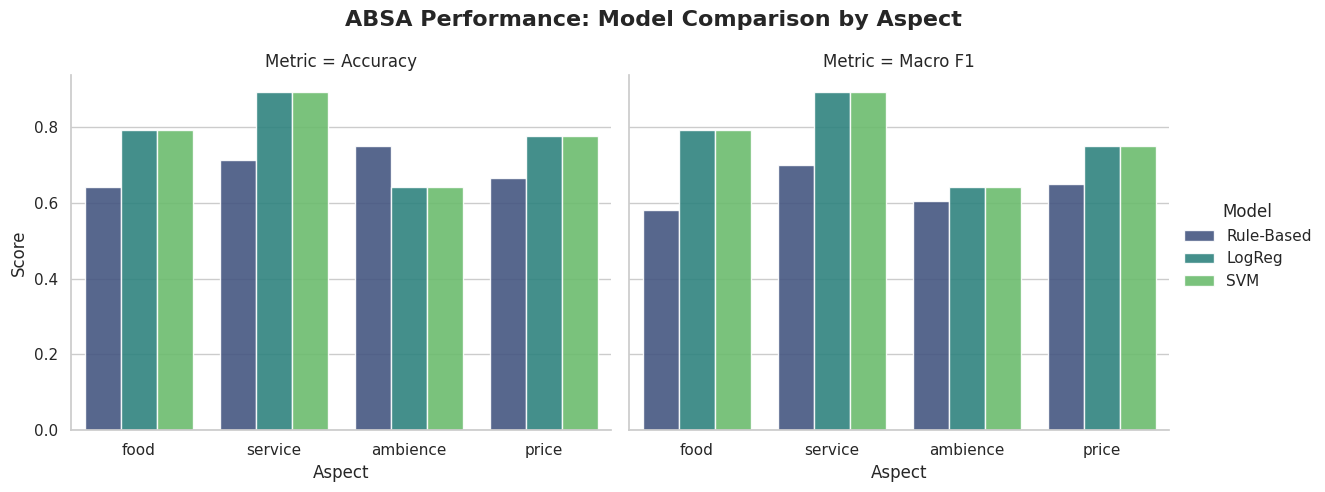

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Melt the dataframe to easily plot both Accuracy and Macro F1
df_melted = evaluation_df.melt(
    id_vars=['Aspect', 'Model'],
    value_vars=['Accuracy', 'Macro F1'],
    var_name='Metric',
    value_name='Score'
)

# Create a grouped bar chart
g = sns.catplot(
    data=df_melted, kind="bar",
    x="Aspect", y="Score", hue="Model", col="Metric",
    palette="viridis", alpha=.9, height=5, aspect=1.2
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('ABSA Performance: Model Comparison by Aspect', fontsize=16, fontweight='bold')
plt.show()

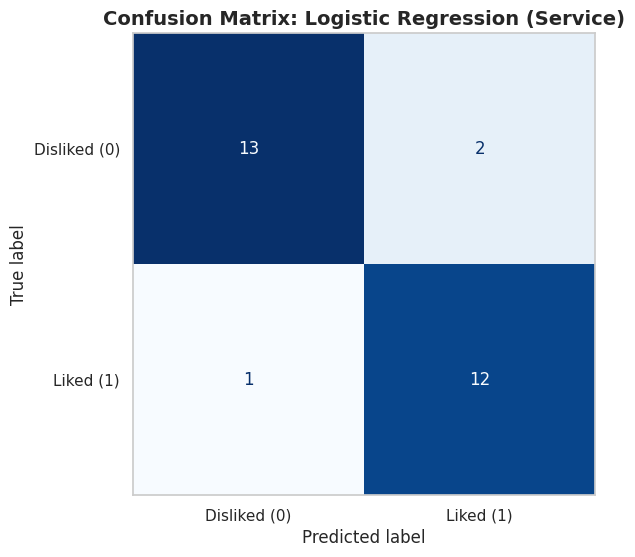

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Let's rebuild just the Service Logistic Regression model to visualize its errors
service_df = df[df['Aspects'].apply(lambda x: 'service' in x)].copy()
X = service_df['Cleaned_Review']
y = service_df['Liked']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=3000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(C=10, max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

# Plot the matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Disliked (0)', 'Liked (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix: Logistic Regression (Service)', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()